Install YOLO

In [ ]:
!pip install ultralytics

Import Libraries

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from pathlib import Path

Load the YOLOv8 Model

In [ ]:
model = YOLO("yolov8n.pt")

Upload an Image

In [ ]:
uploaded = files.upload()

Saving street.jpg to street.jpg


Run Object Detection

In [ ]:
image_path = list(uploaded.keys())[0]

results = model.predict(
    source=image_path,
    save=True
)


image 1/1 /content/street.jpg: 640x544 4 persons, 5 motorcycles, 1 stop sign, 210.4ms
Speed: 3.5ms preprocess, 210.4ms inference, 8.0ms postprocess per image at shape (1, 3, 640, 544)
Results saved to /content/runs/detect/predict-2


Display the Output Image

Saved Image: /content/runs/detect/predict-2/street.jpg


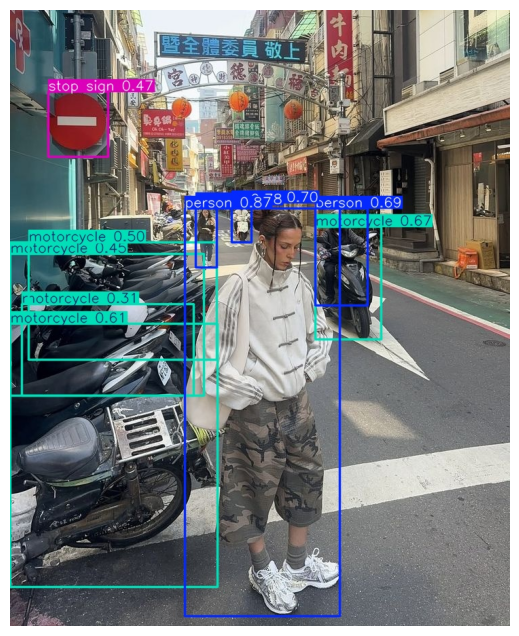

In [ ]:
saved_image = list(Path(results[0].save_dir).glob("*"))[0]

print("Saved Image:", saved_image)

img = cv2.imread(str(saved_image))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

Print Detected Objects

In [ ]:
print("Detected Objects")
print("-"*30)

for r in results:
    for box in r.boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        print(f"{model.names[class_id]} : {confidence:.2f}")

Detected Objects
------------------------------
person : 0.87
person : 0.78
person : 0.70
person : 0.69
motorcycle : 0.67
motorcycle : 0.61
motorcycle : 0.50
stop sign : 0.47
motorcycle : 0.45
motorcycle : 0.31


Download the Output Image

In [ ]:
files.download(str(saved_image))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>